# Helmholtz Equation 1D with PINNs with PML Boundary Conditions - Inverse Problem

This code is based on the following tutorial: 

Manuela Bastidas Olivares, Nicolás Guarín-Zapata. (2024). nicoguaro/pinns_mapi-3: Tutorial de PINNs MAPI-3 v1.0 (v1.0). Zenodo. https://doi.org/10.5281/zenodo.11974585

In [1]:
%matplotlib inline

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.autograd import grad

In [3]:
class UModel(torch.nn.Module):
    def __init__(self, neurons, n_layers, activation=torch.sin):
        super(UModel, self).__init__()
        self.activation = activation
        self.layers = torch.nn.ModuleList()
        self.layers.append(torch.nn.Linear(1, neurons))
        for _ in range(n_layers-2):
            self.layers.append(torch.nn.Linear(neurons, neurons))
        self.layers.append(torch.nn.Linear(neurons, 2))

    def forward(self, x):
        for layer in self.layers[:-1]:
            x = self.activation(layer(x))
        x = self.layers[-1](x)
        return x

In [4]:
class VelModel(torch.nn.Module):
    def __init__(self, neurons, n_layers, activation=torch.tanh):
        super(VelModel, self).__init__()
        self.activation = activation
        self.layers = torch.nn.ModuleList()
        self.layers.append(torch.nn.Linear(1, neurons))
        for _ in range(n_layers-2):
            self.layers.append(torch.nn.Linear(neurons, neurons))
        self.layers.append(torch.nn.Linear(neurons, 1))

    def forward(self, x):
        for layer in self.layers[:-1]:
            x = self.activation(layer(x))
        x = self.layers[-1](x)
        return x

In [5]:
frequency = 5
u_max = 0.000598413420602149
u_model = UModel(neurons=40, n_layers=5)
u_model.load_state_dict(torch.load('h_eq1d_pinnd_pml_model.pth'))
u_model.eval()

UModel(
  (layers): ModuleList(
    (0): Linear(in_features=1, out_features=40, bias=True)
    (1-3): 3 x Linear(in_features=40, out_features=40, bias=True)
    (4): Linear(in_features=40, out_features=2, bias=True)
  )
)

In [ ]:
def f_rhs(x, phase=torch.pi/6, sigma=0.01, amplitude=1.0, src_pos=-0.2):
    return amplitude*torch.exp(-((x - src_pos)**2) / (2 * sigma**2))*np.exp(1j*phase)

def e_x(x, freq, lpml=0.5):
    sigma_x = torch.where(
        torch.abs(x) >= 1 - lpml, 
        2*torch.pi*4*freq*((torch.abs(x)-(1 - lpml))/lpml)**2,
        0
    )
    
    return 1 - 1j * sigma_x / (2*torch.pi*freq)


def residual(u, x, f, e_x, freq, vel):
    u_real = u[:,0:1]
    u_imag = u[:,1:2]
    u_comp = torch.complex(u_real, u_imag)
    
    # Compute gradients for real and imaginary parts separately
    du_real = grad(u_real, x, grad_outputs=torch.ones_like(u_real), create_graph=True)[0]
    du_imag = grad(u_imag, x, grad_outputs=torch.ones_like(u_imag), create_graph=True)[0]
    
    # Second derivatives
    ddu_real = grad(du_real, x, grad_outputs=torch.ones_like(du_real), create_graph=True)[0]
    ddu_imag = grad(du_imag, x, grad_outputs=torch.ones_like(du_imag), create_graph=True)[0]
    ddu_comp = torch.complex(ddu_real, ddu_imag)

    wave_number = 2*torch.pi*freq/vel

    return ddu_comp*u_max +  e_x(x, freq) * u_comp*u_max * wave_number**2 - f(x)


def loss_fn(vel_model, x, f, e_x, freq, u):
    vel = vel_model(x)
    res = residual(u, x, f, e_x, freq, vel)
    res_MSE = torch.mean(torch.abs(res)**2)
    return res_MSE


def train(model, optimizer, scheduler, loss_fn, f, e_x, n_pts, iterations, freq, u_model):
    losses = []
    for iteration in range(iterations):  
        optimizer.zero_grad()
        x = torch.FloatTensor(n_pts,1).uniform_(-1., 1.).requires_grad_(True)
        u = u_model(x)
        loss = loss_fn(model, x, f, e_x, freq, u)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
        scheduler.step()

        current_lr = optimizer.param_groups[0]['lr']
        
        if (iteration+1) % 100 == 0:
            print(f"Epoch {iteration+1}, LR: {current_lr:.8f}, Loss: {loss.item():.4f}")
    return losses

def train_lbfgs(model, optimizer_lbfgs, loss_fn, f, iterations, e_x, x, freq, u_model):

    def closure():
        optimizer_lbfgs.zero_grad()
        u = u_model(x)
        loss = loss_fn(model, x, f, e_x, freq, u)
        loss.backward()
        return loss
    
    losses = []
    for iteration in range(iterations): 
        loss = optimizer_lbfgs.step(closure)
        losses.append(loss.item())
        if (iteration+1) % 100 == 0:
            print(f"[L-BFGS] Epoch {iteration+1}, Loss: {loss.item():.4f}")
        
    return losses

In [14]:
nn = 40
nl = 5
vel_model = VelModel(neurons=nn, n_layers=nl)
for layer in vel_model.layers:
    torch.nn.init.xavier_uniform_(layer.weight, gain=torch.nn.init.calculate_gain('tanh'))  # Xavier/Glorot initialization
optimizer = torch.optim.Adam(vel_model.parameters(), lr=1e-3)

# Número de parámetros
sum(p.numel() for p in vel_model.parameters() if p.requires_grad)

5041

In [15]:
n_pts = 1000
iterations = 1000

In [16]:
start_lr = 1e-3
end_lr = 1e-3
gamma = (end_lr / start_lr) ** (1 / iterations)  # exponential decay factor

# Exponential scheduler
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=gamma)

In [17]:
losses_adam = train(vel_model, optimizer, scheduler, loss_fn, f_rhs, e_x, n_pts, iterations, frequency, u_model)

Iteration 0, Loss 0.015753980726003647
Epoch 0, LR: 0.00100000, Loss: 0.0158
Iteration 100, Loss 0.0007870235713198781
Epoch 100, LR: 0.00100000, Loss: 0.0008
Iteration 200, Loss 0.0004876067687291652
Epoch 200, LR: 0.00100000, Loss: 0.0005
Iteration 300, Loss 0.00032268473296426237
Epoch 300, LR: 0.00100000, Loss: 0.0003
Iteration 400, Loss 0.00029830430867150426
Epoch 400, LR: 0.00100000, Loss: 0.0003
Iteration 500, Loss 0.00019524633535183966
Epoch 500, LR: 0.00100000, Loss: 0.0002
Iteration 600, Loss 0.00015109428204596043
Epoch 600, LR: 0.00100000, Loss: 0.0002
Iteration 700, Loss 0.00012936946586705744
Epoch 700, LR: 0.00100000, Loss: 0.0001
Iteration 800, Loss 0.00011716820154106244
Epoch 800, LR: 0.00100000, Loss: 0.0001
Iteration 900, Loss 9.134873835137114e-05
Epoch 900, LR: 0.00100000, Loss: 0.0001


(-4.0, 0.0)

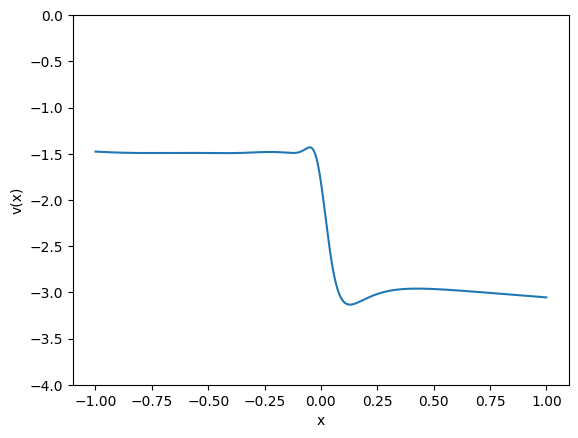

In [18]:
xlist = np.linspace(-1., 1., n_pts)
xlist_torch = torch.tensor(xlist, dtype=torch.float32, requires_grad=True).view(-1, 1)
vel_ap = vel_model(xlist_torch)
fig, ax = plt.subplots()
plt.plot(xlist, vel_ap.detach().numpy())
plt.xlabel("x")
plt.ylabel("v(x)")
ax.set_ylim(-4, 0)

In [19]:
optimizer_lbfgs = torch.optim.LBFGS(vel_model.parameters(), lr=1, max_iter=20)
xlist_torch = torch.FloatTensor(n_pts,1).uniform_(-1., 1.).requires_grad_(True)

In [20]:
iterations = 300
losses_lbfgs = train_lbfgs(vel_model, optimizer_lbfgs, loss_fn, f_rhs, iterations, e_x, xlist_torch, frequency, u_model)

[L-BFGS] Epoch 0, Loss: 0.0001
[L-BFGS] Epoch 100, Loss: 0.0000
[L-BFGS] Epoch 200, Loss: 0.0000


In [21]:
losses = losses_adam + losses_lbfgs

(-4.0, 0.0)

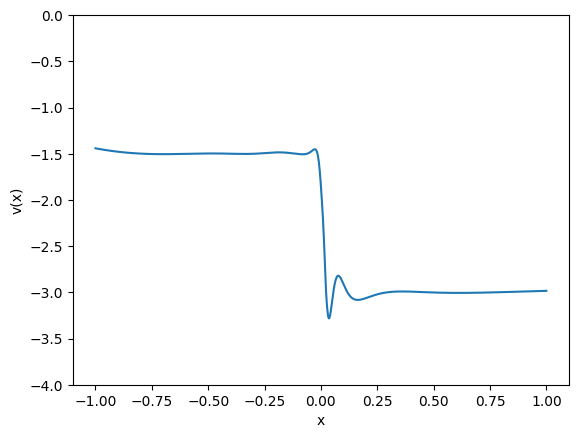

In [23]:
xlist = np.linspace(-1., 1., n_pts)
xlist_torch = torch.tensor(xlist, dtype=torch.float32, requires_grad=True).view(-1, 1)
vel_ap = vel_model(xlist_torch)
fig, ax = plt.subplots()
plt.plot(xlist, vel_ap.detach().numpy())
plt.xlabel("x")
plt.ylabel("v(x)")
ax.set_ylim(-4, 0)

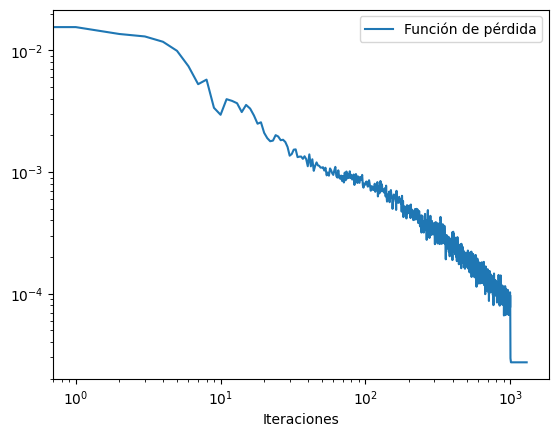

In [24]:
fig, ax = plt.subplots()
plt.loglog(losses)
plt.xlabel("Iteraciones")
plt.legend(['Función de pérdida'])

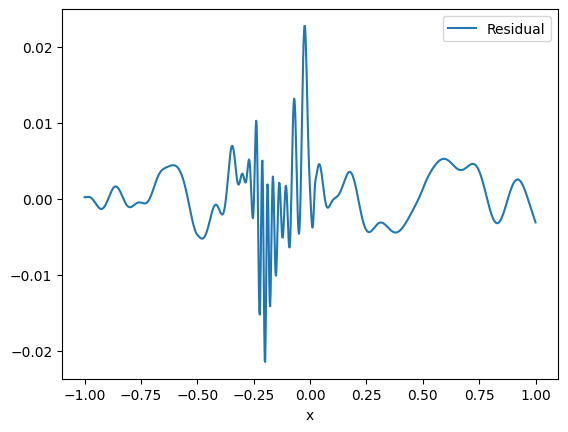

In [25]:
fig, ax = plt.subplots()
plt.plot(xlist, np.real(residual(u_model(xlist_torch), xlist_torch, f_rhs, e_x, frequency, vel_ap).detach().numpy()))
plt.xlabel("x")
plt.legend(["Residual"])

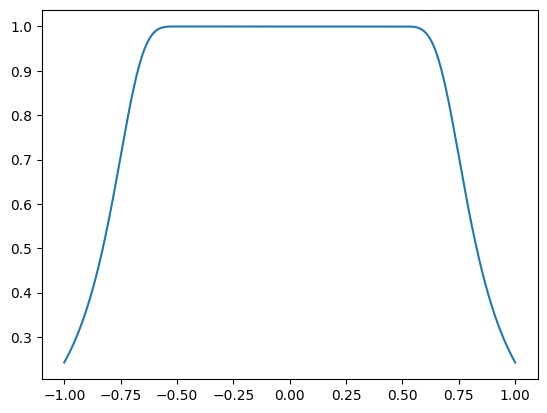

In [26]:
plt.figure()
plt.plot(xlist, np.abs(1/e_x(xlist_torch, freq=5).detach().numpy()))

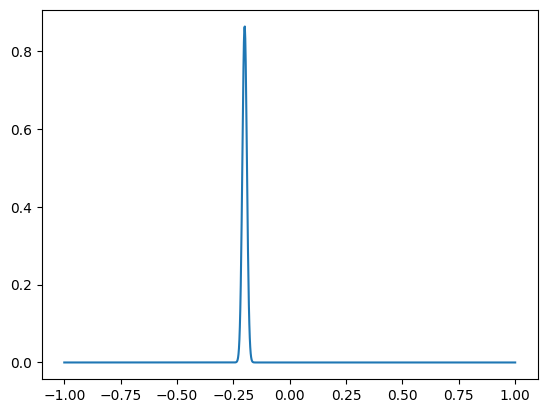

In [27]:
plt.figure()
plt.plot(xlist, np.real(f_rhs(xlist_torch).detach().numpy()))